# Desafio TelecomX Latam

### Mervy Rita Mulatillo Piñin
### Grupo: 09

#📌 Extracción

In [9]:
# ==============================================================================
# 1. IMPORTACIÓN DE BIBLIOTECAS
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# ==============================================================================
# 2. EXTRACCIÓN Y CARGA DE DATOS (API JSON)
# ==============================================================================
print("--- Iniciando Extracción de Datos ---")
url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/main/TelecomX_Data.json"

# Cargamos el JSON y lo "aplanamos" para que las columnas anidadas sean legibles
df_raw = pd.read_json(url)
df = pd.json_normalize(df_raw.to_dict('records'))

print(f"Dataset cargado con {df.shape[0]} filas y {df.shape[1]} columnas.")

--- Iniciando Extracción de Datos ---
Dataset cargado con 7267 filas y 21 columnas.


#🔧 Transformación

In [11]:
# ==============================================================================
# 3. LIMPIEZA Y TRATAMIENTO DE DATOS (ETL)
# ==============================================================================
# A. Corregir columna de cargos totales (contiene espacios vacíos " ")
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')
# Los clientes con tenure 0 (nuevos) tienen NaN en Total, los llenamos con 0
df['account.Charges.Total'] = df['account.Charges.Total'].fillna(0)

# B. Verificar duplicados
duplicados = df.duplicated().sum()
print(f"Duplicados encontrados: {duplicados}")
df.drop_duplicates(inplace=True)

# C. Estandarización: Renombrar columnas al español para el informe
traduccion_columnas = {
    'Churn': 'Evasion',
    'customer.gender': 'Genero',
    'customer.SeniorCitizen': 'Adulto_Mayor',
    'customer.tenure': 'Meses_Contrato',
    'account.Contract': 'Tipo_Contrato',
    'account.PaymentMethod': 'Metodo_Pago',
    'account.Charges.Monthly': 'Cargo_Mensual',
    'account.Charges.Total': 'Cargo_Total'
}
df.rename(columns=traduccion_columnas, inplace=True)

# D. Transformación de datos: Convertir valores Yes/No a binarios (1/0)
# Esto facilita el cálculo de correlaciones y promedios de evasión
df['Evasion_Binaria'] = df['Evasion'].map({'Yes': 1, 'No': 0})

Duplicados encontrados: 0


#📊 Carga y análisis


--- Resumen Estadístico de Variables Numéricas ---


,Meses_Contrato,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
count,7267.000000,7267.000000,7267.000000,7267.000000
mean,32.346498,64.720098,2277.182035,2.157292
std,24.571773,30.129572,2268.648587,1.004407
min,0.000000,18.250000,0.000000,0.610000
25%,9.000000,35.425000,396.200000,1.180000
50%,29.000000,70.300000,1389.200000,2.340000
75%,55.000000,89.875000,3778.525000,2.995000
max,72.000000,118.750000,8684.800000,3.960000


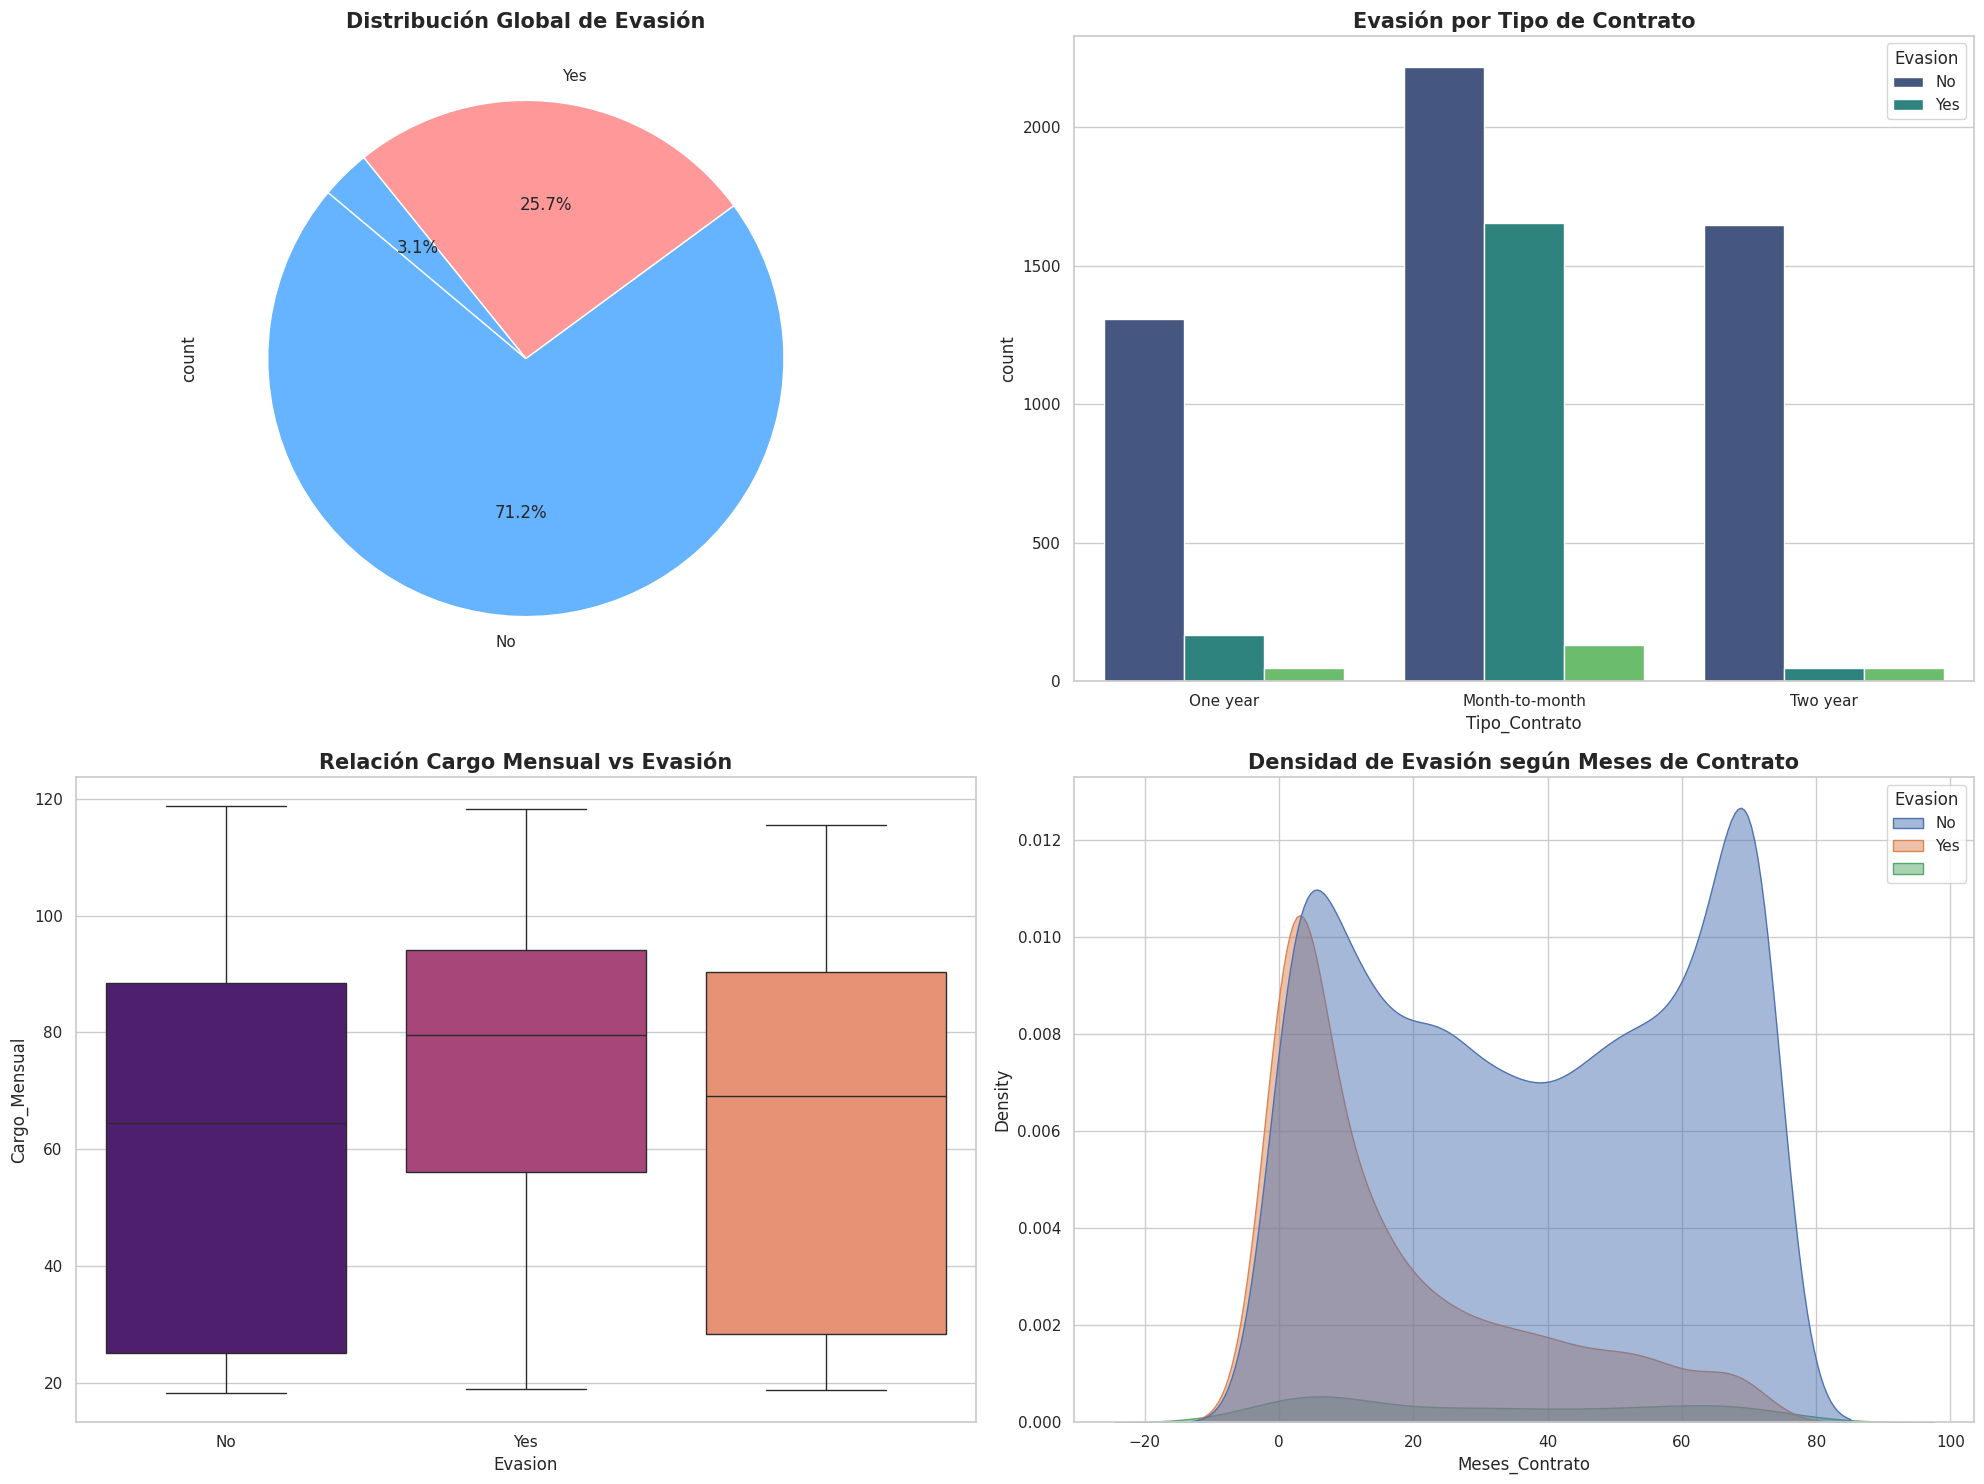

In [13]:
# ==============================================================================
# 4. CREACIÓN DE NUEVAS MÉTRICAS
# ==============================================================================
# Calcular el valor diario de la facturación mensual
df['Cuentas_Diarias'] = (df['Cargo_Mensual'] / 30).round(2)

# ==============================================================================
# 5. ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# ==============================================================================
print("\n--- Resumen Estadístico de Variables Numéricas ---")
display(df[['Meses_Contrato', 'Cargo_Mensual', 'Cargo_Total', 'Cuentas_Diarias']].describe())

# Configuración visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(20, 15))

# GRÁFICO 1: Distribución Global de Evasión (Churn)
plt.subplot(2, 2, 1)
df['Evasion'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=140)
plt.title('Distribución Global de Evasión', fontsize=15, fontweight='bold')

# GRÁFICO 2: Evasión según Tipo de Contrato (Variable Categórica)
plt.subplot(2, 2, 2)
sns.countplot(data=df, x='Tipo_Contrato', hue='Evasion', palette='viridis')
plt.title('Evasión por Tipo de Contrato', fontsize=15, fontweight='bold')

# GRÁFICO 3: Cargos Mensuales vs Evasión (Variable Numérica)
plt.subplot(2, 2, 3)
sns.boxplot(data=df, x='Evasion', y='Cargo_Mensual', hue='Evasion', palette='magma', legend=False)
plt.title('Relación Cargo Mensual vs Evasión', fontsize=15, fontweight='bold')

# GRÁFICO 4: Tiempo de Permanencia vs Evasión
plt.subplot(2, 2, 4)
sns.kdeplot(data=df, x='Meses_Contrato', hue='Evasion', fill=True, alpha=0.5)
plt.title('Densidad de Evasión según Meses de Contrato', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

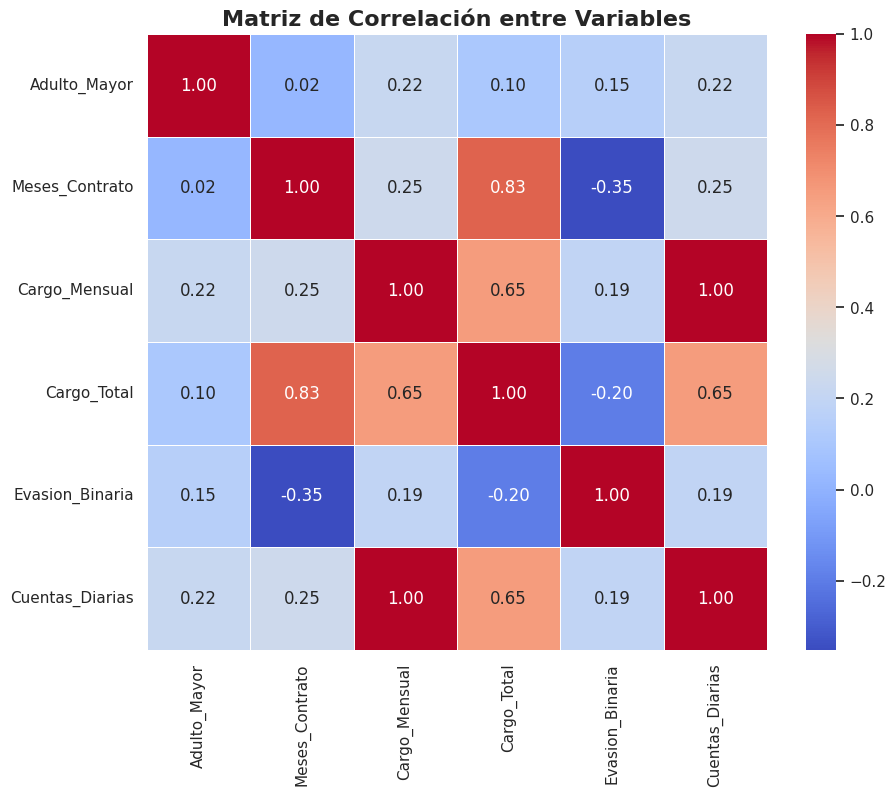


--- Desafío Telecom X Finalizado ---


In [14]:
# ==============================================================================
# 6. ACTIVIDAD EXTRA: MATRIZ DE CORRELACIÓN
# ==============================================================================
plt.figure(figsize=(10, 8))
# Seleccionamos solo columnas numéricas para la correlación
columnas_numericas = df.select_dtypes(include=[np.number])
correlacion = columnas_numericas.corr()

sns.heatmap(correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación entre Variables', fontsize=16, fontweight='bold')
plt.show()

print("\n--- Desafío Telecom X Finalizado ---")

#📄Informe final

📋 Informe Final de Análisis: Evasión de Clientes (Churn) - Telecom X

🔹 1. Introducción

El objetivo de este proyecto es analizar el fenómeno de la evasión de clientes (conocido como Churn) en la empresa Telecom X.

La pérdida de clientes no solo representa una disminución en los ingresos directos, sino que también incrementa los costos operativos, ya que adquirir un nuevo cliente es significativamente más costoso que retener a uno actual. A través de este análisis, buscamos identificar patrones demográficos y de consumo que permitan al equipo de analítica de datos desarrollar estrategias de retención efectivas.
#
🔹 2. Limpieza y Tratamiento de Datos.

Para asegurar la integridad de los resultados, se realizó un proceso de ETL (Extracción, Transformación y Carga) que incluyó:
* Importación: Se consumieron los datos en formato JSON directamente desde la API de la empresa.
* Normalización: Debido a la estructura anidada del archivo, se utilizó json_normalize para aplanar las categorías de clientes, servicios y cuentas en un solo DataFrame.
* Depuración:
Se identificaron y corrigieron inconsistencias en la columna de Cargos Totales, convirtiendo valores de texto con espacios vacíos a formato numérico.
Se eliminaron registros duplicados y se gestionaron valores nulos en clientes con antigüedad cero.
* Ingeniería de Características: Se creó la métrica "Cuentas_Diarias" (Cargo Mensual / 30) y se transformó la variable objetivo Churn a formato binario para facilitar el análisis estadístico.

#
🔹 3. Análisis Exploratorio de Datos (EDA)

* El análisis se centró en identificar las variables que "mueven la aguja" en la decisión del cliente de abandonar la empresa.
* Distribución Global: El 25.7% de la base de datos presenta evasión. Es una tasa crítica que requiere intervención inmediata.
* Análisis Contractual: El gráfico de barras revela que el contrato "Month-to-month" es el principal foco de fuga. Los clientes con contratos a largo plazo (1 o 2 años) muestran una lealtad significativamente mayor.
* Sensibilidad al Costo: Mediante el boxplot, observamos que los clientes que evaden tienden a tener cargos mensuales más altos (mediana cercana a $80) comparados con los clientes leales (mediana cercana a $65).
* Factor Tiempo (Tenure): El gráfico de densidad (KDE) muestra un pico de cancelaciones durante los primeros 6 meses. Una vez superado el primer año, la probabilidad de abandono cae drásticamente.
* Correlaciones: La matriz de correlación confirmó una relación negativa entre la permanencia y la evasión, validando que el tiempo de contrato es el mejor escudo contra el churn.
#
🔹 4. Conclusiones e Insights
* El "Mes a Mes" es el riesgo #1: La flexibilidad del contrato sin permanencia facilita que el cliente se retire ante cualquier insatisfacción o oferta de la competencia.
* Barrera del Primer Año: Los primeros meses son críticos. Si no se logra fidelizar al cliente en su primer semestre, es muy probable que se retire.
* Fuga de "Alto Valor": No solo se van muchos clientes, sino que se van aquellos que pagan facturas más altas, lo que impacta severamente el flujo de caja.

---

###### Elaborado por: Mervy Mulatillo Piñin
###### Fecha: Marzo 2026
###### Proyecto: Telecom X Churn Analysis - Data Science Challenge